# 15 — PID control (`math`, SciPy, PyTorch, python-control)

Close the loop around the underdamped plant from notebook `14`:

$$
C(s) = K_p + \frac{K_i}{s} + \frac{K_d s}{\tau_d s + 1}, \qquad T(s) = \frac{C G}{1 + C G}.
$$

python-control builds \(T(s)\) and reports margins. `math` / SciPy / PyTorch integrate the same plant+PID in discrete time. The GPU batches a **grid of \(K_p\)**.

In [1]:
from __future__ import annotations

import math
import time

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")
if device.type == "cuda":
    print(f"CUDA {torch.version.cuda}  |  {torch.cuda.get_device_name(0)}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda
CUDA 13.2  |  NVIDIA GeForce RTX 3060


In [2]:
def bode_mag_phase(sys, omega):
    frd = ct.frequency_response(sys, omega=omega)
    if hasattr(frd, "magnitude"):
        w = np.asarray(frd.frequency).reshape(-1)
        m = np.asarray(frd.magnitude).reshape(-1)
        p = np.asarray(frd.phase).reshape(-1)
    else:
        mag, phase, om = frd
        w = np.asarray(om).reshape(-1)
        m = np.asarray(mag).reshape(-1)
        p = np.asarray(phase).reshape(-1)
    return w, m, p


def plot_bode(sys, title, marks=()):
    w, m, p = bode_mag_phase(sys, np.logspace(0, 5, 500))
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
    axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p)))
    for f, lab in marks:
        axes[0].axvline(f, color="k", ls="--", lw=1, label=lab)
        axes[1].axvline(f, color="k", ls="--", lw=1)
    axes[0].set_ylabel("mag (dB)")
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_xlabel("frequency (Hz)")
    for ax in axes:
        ax.grid(True, which="both", alpha=0.3)
    if marks:
        axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return w, m, p


def max_abs(a, b) -> float:
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))


In [3]:
FS_HZ = 8_192
DURATION_S = 0.60
FN_HZ = 12.0
ZETA = 0.15
KP, KI, KD, TD = 1.8, 40.0, 0.012, 0.002
N = int(FS_HZ * DURATION_S)
DT = 1.0 / FS_HZ
WN = 2.0 * math.pi * FN_HZ

t = np.arange(N, dtype=np.float64) / FS_HZ
r = np.ones(N, dtype=np.float64)
print(f"plant fn={FN_HZ} Hz  ζ={ZETA}   PID=({KP}, {KI}, {KD})  td={TD}   device={device}")

plant fn=12.0 Hz  ζ=0.15   PID=(1.8, 40.0, 0.012)  td=0.002   device=cuda


## python-control — open plant vs closed loop

C(s) =
<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.0156 s^2 + 1.88 s + 40
  ------------------------
       0.002 s^2 + s
T(s) poles [-421.68  +0.j  -42.74+125.j  -42.74-125.j  -15.45  +0.j]
loop margins  GM=inf  PM=42.46 deg  wgc=141.6 rad/s


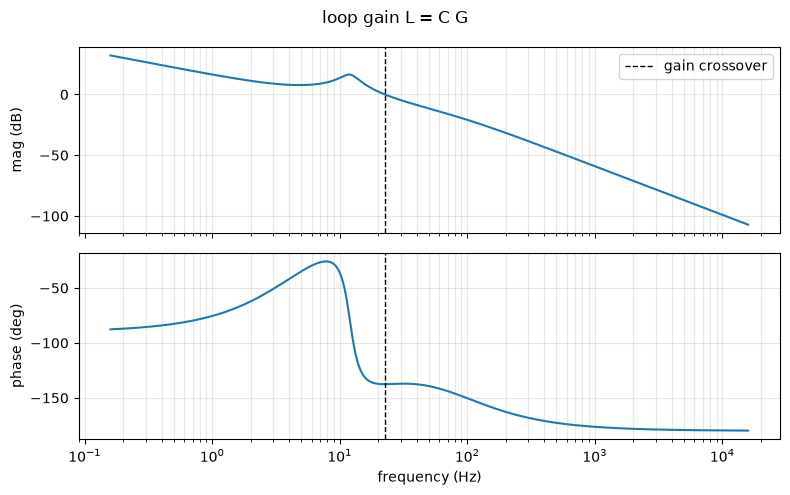

(array([1.00000000e+00, 1.02334021e+00, 1.04722519e+00, 1.07166765e+00,
        1.09668060e+00, 1.12227736e+00, 1.14847155e+00, 1.17527712e+00,
        1.20270833e+00, 1.23077980e+00, 1.25950646e+00, 1.28890361e+00,
        1.31898690e+00, 1.34977233e+00, 1.38127630e+00, 1.41351558e+00,
        1.44650734e+00, 1.48026913e+00, 1.51481892e+00, 1.55017512e+00,
        1.58635653e+00, 1.62338243e+00, 1.66127252e+00, 1.70004698e+00,
        1.73972643e+00, 1.78033202e+00, 1.82188534e+00, 1.86440853e+00,
        1.90792422e+00, 1.95245558e+00, 1.99802631e+00, 2.04466067e+00,
        2.09238348e+00, 2.14122015e+00, 2.19119669e+00, 2.24233968e+00,
        2.29467637e+00, 2.34823460e+00, 2.40304289e+00, 2.45913043e+00,
        2.51652705e+00, 2.57526333e+00, 2.63537052e+00, 2.69688063e+00,
        2.75982639e+00, 2.82424133e+00, 2.89015972e+00, 2.95761666e+00,
        3.02664806e+00, 3.09729067e+00, 3.16958209e+00, 3.24356081e+00,
        3.31926620e+00, 3.39673858e+00, 3.47601918e+00, 3.557150

In [4]:
G = ct.tf([WN**2], [1.0, 2.0 * ZETA * WN, WN**2])
C = ct.tf([KP], [1]) + ct.tf([KI], [1, 0]) + ct.tf([KD, 0], [TD, 1])
T = ct.feedback(C * G, 1)
print("C(s) ="); print(C)
print("T(s) poles", np.round(ct.poles(T), 2))
gm, pm, _wpc, wgc = ct.margin(C * G)
print(f"loop margins  GM={gm}  PM={pm:.2f} deg  wgc={wgc:.1f} rad/s")

_, y_ol = ct.forced_response(G, T=t, U=r)
_, y_cl = ct.forced_response(T, T=t, U=r)
plot_bode(C * G, "loop gain L = C G", marks=[(wgc / (2 * math.pi), "gain crossover")])

## `math` — discrete PID + Euler plant

Filtered derivative (backward Euler):

$$
d[n] = \frac{\tau_d}{\tau_d+\\Delta t}\, d[n-1] + \frac{K_d}{\tau_d+\\Delta t}\\,(e[n]-e[n-1]).
$$

In [5]:
def math_pid_closed(r_list, dt, wn, zeta, kp, ki, kd, td):
    x1 = 0.0
    x2 = 0.0
    integ = 0.0
    d = 0.0
    e_prev = 0.0
    y = 0.0
    two_z_wn = 2.0 * zeta * wn
    wn2 = wn * wn
    a_d = td / (td + dt)
    b_d = kd / (td + dt)
    ys = []
    us = []
    for r_n in r_list:
        e = r_n - y
        integ = integ + ki * dt * e
        d = a_d * d + b_d * (e - e_prev)
        e_prev = e
        u = kp * e + integ + d
        dx1 = x2
        dx2 = -wn2 * x1 - two_z_wn * x2 + wn2 * u
        x1 = x1 + dt * dx1
        x2 = x2 + dt * dx2
        y = x1
        ys.append(y)
        us.append(u)
    return ys, us


y_math, u_math = math_pid_closed(r.tolist(), DT, WN, ZETA, KP, KI, KD, TD)
print(f"math final y={y_math[-1]:.4f}  overshoot={(max(y_math)-1)*100:.2f}%")

math final y=1.0000  overshoot=8.77%


## SciPy — `lsim` of the python-control closed-loop state-space

In [6]:
ss_t = ct.tf2ss(T)
sys_sp = signal.StateSpace(ss_t.A, ss_t.B, ss_t.C, ss_t.D)
_tout, y_sp, _x = signal.lsim(sys_sp, U=r, T=t)
y_sp = np.asarray(y_sp).reshape(-1)
print(f"scipy lsim final={y_sp[-1]:.4f}   vs control {max_abs(y_cl, y_sp):.3e}")

scipy lsim final=1.0000   vs control 2.498e-14


## PyTorch — batched PID over a \(K_p\) grid

Same plant, 24 proportional gains, all state tensors on `cuda`. Time stays a Python loop; each step is a length-24 vector add on the GPU.

In [7]:
def torch_pid_batch(r_t, dt, wn, zeta, kp, ki, kd, td):
    # r_t: (T,), kp: (B,), others scalar
    B = kp.numel()
    T = r_t.numel()
    r_b = r_t.expand(B, T)
    x1 = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    x2 = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    integ = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    d = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    e_prev = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    y = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    two_z_wn = 2.0 * zeta * wn
    wn2 = wn * wn
    a_d = td / (td + dt)
    b_d = kd / (td + dt)
    out = torch.empty(B, T, device=r_t.device, dtype=r_t.dtype)
    for i in range(T):
        e = r_b[:, i] - y
        integ = integ + ki * dt * e
        d = a_d * d + b_d * (e - e_prev)
        e_prev = e
        u = kp * e + integ + d
        dx1 = x2
        dx2 = -wn2 * x1 - two_z_wn * x2 + wn2 * u
        x1 = x1 + dt * dx1
        x2 = x2 + dt * dx2
        y = x1
        out[:, i] = y
    return out


r_th = torch.as_tensor(r, device=device, dtype=torch.float32)
kp_grid = torch.linspace(0.4, 4.0, 24, device=device, dtype=torch.float32)
if device.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
y_batch = torch_pid_batch(r_th, DT, WN, ZETA, kp_grid, KI, KD, TD)
if device.type == "cuda":
    torch.cuda.synchronize()
print(f"PID batch {tuple(y_batch.shape)} on {y_batch.device} in {(time.perf_counter()-t0)*1e3:.1f} ms")

i_nom = int(torch.argmin(torch.abs(kp_grid - KP)).item())
y_gpu = y_batch[i_nom].detach().cpu().numpy()
print(f"nom Kp={float(kp_grid[i_nom]):.3f}  math vs torch {max_abs(y_math, y_gpu):.3e}")

PID batch (24, 4915) on cuda:0 in 743.7 ms
nom Kp=1.809  math vs torch 1.741e-03


## Overlay + gain sweep

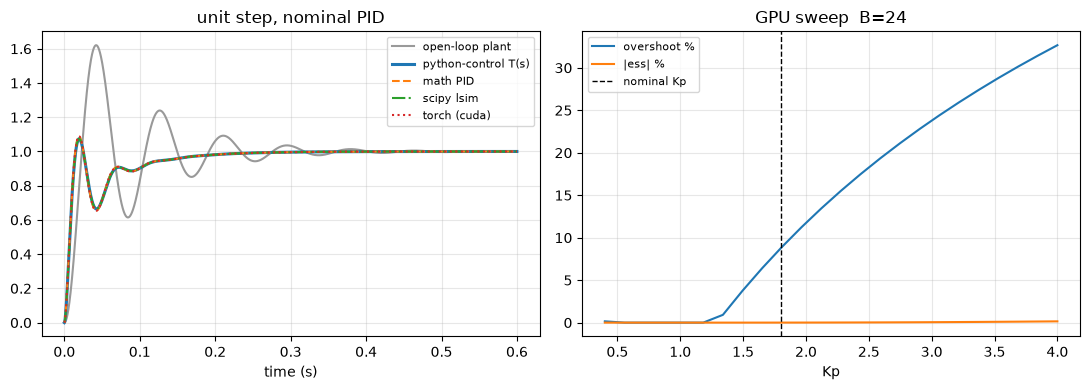

control vs math 1.683e-02  (Euler + filtered-D vs continuous T(s))


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, y_ol, color="0.6", label="open-loop plant")
axes[0].plot(t, y_cl, lw=2.2, label="python-control T(s)")
axes[0].plot(t, y_math, ls="--", label="math PID")
axes[0].plot(t, y_sp, ls="-.", label="scipy lsim")
axes[0].plot(t, y_gpu, ls=":", label=f"torch ({device})")
axes[0].set_xlabel("time (s)")
axes[0].set_title("unit step, nominal PID")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

os = (y_batch.max(dim=1).values - 1.0).clamp(min=0).detach().cpu().numpy()
final = y_batch[:, -1].detach().cpu().numpy()
kp_np = kp_grid.detach().cpu().numpy()
axes[1].plot(kp_np, os * 100, label="overshoot %")
axes[1].plot(kp_np, np.abs(final - 1.0) * 100, label="|ess| %")
axes[1].axvline(KP, color="k", ls="--", lw=1, label="nominal Kp")
axes[1].set_xlabel("Kp")
axes[1].set_title(f"GPU sweep  B={len(kp_np)}")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"control vs math {max_abs(y_cl, y_math):.3e}  (Euler + filtered-D vs continuous T(s))")

## Takeaways

- python-control writes \(C(s)\) and \(T(s)\) once; Bode of \(L=CG\) is the stability check.
- Discrete PID + Euler plant tracks \(T(s)\) when \(f_s\) is far above the crossover.
- SciPy `lsim` on `tf2ss(T)` is the independent continuous-time check.
- GPU parallelism here is a **gain grid**, not a longer IIR. Next (`16`): shape \(L(j\omega)\) with lead / lag.